# Analyse des vues LLM dans les portefeuilles Black-Litterman blended

Ce notebook analyse les vues utilisées dans les nouveaux portefeuilles BL blended.

Il produit notamment :

- corrélation des vues avec les rendements réalisés du mois suivant;
- hit rate des signes;
- top/bottom spread des vues;
- analyse par régime de marché;
- comparaison des vues entre modèles;
- lien entre vues, poids actifs et rendement actif;
- exports CSV/Excel pour le rapport.

Convention temporelle utilisée :

> vues et poids du mois M → rendements réalisés du mois M+1


In [4]:
import os
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.options.display.float_format = "{:,.4f}".format

# ============================
# Configuration
# ============================

DATASET_PATH = Path("../data/filtered_sp25_data.csv")
RESPONSES_DIR = Path("../responses")
RESULTS_DIR = Path("../results")
OUT_DIR = Path("diagnostics_views_blended")
OUT_DIR.mkdir(parents=True, exist_ok=True)

START = "2016-06-01"
END = "2025-06-30"
TAU = 0.025

MODELS = ["gpt", "gemma3", "llama", "qwen"]

# Portefeuilles blended/recommandés à analyser.
# Modifier au besoin si les noms de fichiers diffèrent.
PORTFOLIOS_BY_MODEL = {
    "gemma3": [
        "gemma3_blend_alpha_0.25_omega_1",
        "gemma3_blend_alpha_0.5_omega_1",
        "gemma3_omega_x25",
    ],
    "gpt": [
        "gpt_blend_alpha_0.5_omega_1",
        "gpt_omega_x25",
    ],
    "llama": [
        "llama_blend_alpha_0.1_omega_1",
    ],
    "qwen": [
        "qwen_blend_alpha_0.1_omega_1",
    ],
}

print("Modèles analysés:", MODELS)
print("Portefeuilles analysés:")
for m, ids in PORTFOLIOS_BY_MODEL.items():
    print(f"- {m}: {ids}")


Modèles analysés: ['gpt', 'gemma3', 'llama', 'qwen']
Portefeuilles analysés:
- gemma3: ['gemma3_blend_alpha_0.25_omega_1', 'gemma3_blend_alpha_0.5_omega_1', 'gemma3_omega_x25']
- gpt: ['gpt_blend_alpha_0.5_omega_1', 'gpt_omega_x25']
- llama: ['llama_blend_alpha_0.1_omega_1']
- qwen: ['qwen_blend_alpha_0.1_omega_1']


## 1. Fonctions utilitaires


In [5]:
def clean_ticker(x) -> str:
    if x is None:
        return ""
    s = str(x).strip().strip('"').strip("'").upper()
    if not s or s in {"NAN", "NONE"}:
        return ""
    if "-" in s and "." not in s:
        s = s.replace("-", ".")
    return "".join(s.split())

def parse_dates_yyyymmdd(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        ss = pd.to_numeric(s, errors="coerce").astype("Int64").astype(str).str.zfill(8)
        return pd.to_datetime(ss, format="%Y%m%d", errors="coerce")
    ss = s.astype(str).str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    mask = ss.str.match(r"^\d{8}$", na=False)
    out.loc[mask] = pd.to_datetime(ss.loc[mask], format="%Y%m%d", errors="coerce")
    out.loc[~mask] = pd.to_datetime(ss.loc[~mask], errors="coerce")
    return out

def month_starts_between(start: str, end: str) -> pd.DatetimeIndex:
    return pd.date_range(pd.to_datetime(start), pd.to_datetime(end), freq="MS")

def month_end_from_period(p: pd.Period) -> pd.Timestamp:
    return p.to_timestamp(how="end").normalize()

def infer_model_from_portfolio_id(portfolio_id: str) -> str:
    p = str(portfolio_id).lower()
    for m in MODELS:
        if p.startswith(m.lower()):
            return m
    return p.split("_")[0]

def safe_corr(x, y) -> float:
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)
    ok = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan
    if x.loc[ok].std(ddof=1) <= 1e-15 or y.loc[ok].std(ddof=1) <= 1e-15:
        return np.nan
    return float(x.loc[ok].corr(y.loc[ok]))

def hit_rate(x, y) -> float:
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)
    ok = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    ok &= (x != 0) & (y != 0)
    if ok.sum() == 0:
        return np.nan
    return float((np.sign(x.loc[ok]) == np.sign(y.loc[ok])).mean())

def long_short_spread(view: pd.Series, realized: pd.Series, q: float = 0.2) -> float:
    df = pd.concat([view.rename("view"), realized.rename("ret")], axis=1).dropna()
    if len(df) < 5:
        return np.nan
    n = max(1, int(np.floor(q * len(df))))
    top = df.nlargest(n, "view")["ret"].mean()
    bottom = df.nsmallest(n, "view")["ret"].mean()
    return float(top - bottom)

def top_bottom_hit(view: pd.Series, realized: pd.Series, q: float = 0.2) -> float:
    df = pd.concat([view.rename("view"), realized.rename("ret")], axis=1).dropna()
    if len(df) < 5:
        return np.nan
    n = max(1, int(np.floor(q * len(df))))
    top_idx = df.nlargest(n, "view").index
    bottom_idx = df.nsmallest(n, "view").index
    top_good = (df.loc[top_idx, "ret"] > df["ret"].median()).mean()
    bottom_good = (df.loc[bottom_idx, "ret"] < df["ret"].median()).mean()
    return float(0.5 * (top_good + bottom_good))

def annualized_return(r: pd.Series) -> float:
    r = pd.Series(r, dtype=float).dropna()
    if len(r) == 0:
        return np.nan
    return float((1 + r).prod() ** (12 / len(r)) - 1)

def max_drawdown(r: pd.Series) -> float:
    r = pd.Series(r, dtype=float).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return float(dd.min())


## 2. Chargement des données SP25 et calcul du benchmark cap-weighted


In [6]:
def load_sp25_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    required = {"date", "tic", "stock_ret", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {path}: {missing}")
    df = df.copy()
    df["date_dt"] = parse_dates_yyyymmdd(df["date"])
    df["tic"] = df["tic"].map(clean_ticker)
    df["stock_ret"] = pd.to_numeric(df["stock_ret"], errors="coerce")
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")
    df = df.dropna(subset=["date_dt", "tic"]).copy()
    df = df[df["tic"] != ""].copy()
    df["ym"] = df["date_dt"].dt.to_period("M")
    df = df.sort_values(["ym", "tic", "date_dt"])
    df = df.drop_duplicates(["ym", "tic"], keep="last")
    return df

sp25_df = load_sp25_dataset(DATASET_PATH)

returns_panel = (
    sp25_df.pivot(index="ym", columns="tic", values="stock_ret")
    .sort_index()
)

mcap_panel = (
    sp25_df.pivot(index="ym", columns="tic", values="market_equity")
    .sort_index()
)

market_weights = mcap_panel.where(mcap_panel > 0)
market_weights = market_weights.div(market_weights.sum(axis=1), axis=0).fillna(0.0)

def compute_sp25_returns_from_lagged_weights(start: str, end: str) -> pd.Series:
    out = {}
    for m0 in month_starts_between(start, end):
        weight_p = m0.to_period("M")
        target_p = (m0 + pd.offsets.MonthBegin(1)).to_period("M")
        if weight_p not in market_weights.index or target_p not in returns_panel.index:
            continue
        w = market_weights.loc[weight_p]
        r = returns_panel.loc[target_p]
        ok = r.notna() & w.notna() & np.isfinite(r) & np.isfinite(w)
        if ok.sum() == 0:
            continue
        denom = w.loc[ok].sum()
        if denom <= 1e-12:
            continue
        out[month_end_from_period(target_p)] = float((w.loc[ok] * r.loc[ok]).sum() / denom)
    return pd.Series(out, name="sp25_return").sort_index()

sp25_returns = compute_sp25_returns_from_lagged_weights(START, END)

print("Dataset SP25:", returns_panel.index.min(), "->", returns_panel.index.max(), "| tickers:", returns_panel.shape[1])
print("Benchmark S&P25:", sp25_returns.index.min(), "->", sp25_returns.index.max(), "| n:", len(sp25_returns))
display(sp25_returns.head())


Dataset SP25: 2014-12 -> 2025-06 | tickers: 43
Benchmark S&P25: 2016-07-31 00:00:00 -> 2025-06-30 00:00:00 | n: 108


2016-07-31    0.0373
2016-08-31    0.0034
2016-09-30    0.0050
2016-10-31   -0.0137
2016-11-30    0.0189
Name: sp25_return, dtype: float64

## 3. Chargement des vues LLM


In [7]:
def load_response_file(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    out = {}
    for k, v in raw.items():
        t = clean_ticker(k)
        if not t or not isinstance(v, dict):
            continue

        samples = v.get("expected_return", None)

        if isinstance(samples, list):
            s = pd.to_numeric(pd.Series(samples), errors="coerce").dropna()
        else:
            s = pd.to_numeric(pd.Series([samples]), errors="coerce").dropna()

        if len(s) == 0:
            continue

        out[t] = {
            "view_mean": float(s.mean()),
            "view_median": float(s.median()),
            "view_std": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
            "view_var": float(s.var(ddof=1)) if len(s) > 1 else np.nan,
            "view_n": int(len(s)),
        }
    return out

def build_views_panel(models, responses_dir: Path, start: str, end: str) -> pd.DataFrame:
    rows = []
    for m0 in month_starts_between(start, end):
        start_date = m0.strftime("%Y-%m-%d")
        end_date = (m0 + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")
        view_month = m0.to_period("M")
        target_month = (m0 + pd.offsets.MonthBegin(1)).to_period("M")
        target_date = month_end_from_period(target_month)

        for model in models:
            path = responses_dir / f"{model}_{start_date}_{end_date}.json"
            if not path.exists():
                continue

            d = load_response_file(path)
            for tic, vals in d.items():
                realized = np.nan
                if target_month in returns_panel.index and tic in returns_panel.columns:
                    realized = returns_panel.loc[target_month, tic]

                rows.append({
                    "model": model,
                    "view_month": view_month,
                    "view_date": m0,
                    "target_month": target_month,
                    "target_date": target_date,
                    "tic": tic,
                    "realized_next_return": realized,
                    "response_file": path.name,
                    **vals,
                })

    if len(rows) == 0:
        raise ValueError("Aucune vue chargée. Vérifie MODELS, START/END et RESPONSES_DIR.")

    df = pd.DataFrame(rows)
    df["view_sign"] = np.sign(df["view_mean"])
    df["realized_sign"] = np.sign(df["realized_next_return"])
    df["correct_sign"] = (
        df["view_sign"].ne(0)
        & df["realized_sign"].ne(0)
        & (df["view_sign"] == df["realized_sign"])
    )
    return df

views_long = build_views_panel(MODELS, RESPONSES_DIR, START, END)

print("Vues chargées:", views_long.shape)
display(views_long.head())


Vues chargées: (9948, 16)


,model,view_month,view_date,target_month,target_date,tic,realized_next_return,response_file,view_mean,view_median,view_std,view_var,view_n,view_sign,realized_sign,correct_sign
0,gpt,2016-06,2016-06-01,2016-07,2016-07-31,AAPL,0.0901,gpt_2016-06-01_2016-06-30.json,-0.0184,-0.0185,0.0058,0.0000,30,-1.0000,1.0000,False
1,gpt,2016-06,2016-06-01,2016-07,2016-07-31,AMZN,0.0604,gpt_2016-06-01_2016-06-30.json,0.0623,0.0620,0.0074,0.0001,30,1.0000,1.0000,True
2,gpt,2016-06,2016-06-01,2016-07,2016-07-31,BRK.B,-0.0036,gpt_2016-06-01_2016-06-30.json,0.0162,0.0155,0.0033,0.0000,30,1.0000,-1.0000,False
3,gpt,2016-06,2016-06-01,2016-07,2016-07-31,CVX,-0.0224,gpt_2016-06-01_2016-06-30.json,0.0151,0.0170,0.0078,0.0001,30,1.0000,-1.0000,False
4,gpt,2016-06,2016-06-01,2016-07,2016-07-31,GOOG,0.1248,gpt_2016-06-01_2016-06-30.json,-0.0055,-0.0047,0.0059,0.0000,30,-1.0000,1.0000,False


## 4. Diagnostics mensuels des vues


In [8]:
monthly_rows = []

for (model, target_date), g in views_long.groupby(["model", "target_date"]):
    g = g.dropna(subset=["view_mean", "realized_next_return"]).copy()
    if len(g) == 0:
        continue

    view = g.set_index("tic")["view_mean"]
    ret = g.set_index("tic")["realized_next_return"]

    sp25_ret = sp25_returns.loc[target_date] if target_date in sp25_returns.index else np.nan

    if pd.isna(sp25_ret):
        regime = "unknown"
    elif sp25_ret >= 0.03:
        regime = "strong_up"
    elif sp25_ret > 0:
        regime = "up"
    elif sp25_ret <= -0.03:
        regime = "strong_down"
    else:
        regime = "down"

    n_top = max(1, int(0.2 * len(view))) if len(view) >= 5 else np.nan

    monthly_rows.append({
        "model": model,
        "target_date": target_date,
        "n_views": len(g),
        "sp25_return": sp25_ret,
        "market_regime": regime,
        "view_mean_avg": float(view.mean()),
        "view_median_avg": float(view.median()),
        "view_std_cross_section": float(view.std(ddof=1)) if len(view) > 1 else np.nan,
        "view_pos_frac": float((view > 0).mean()),
        "view_neg_frac": float((view < 0).mean()),
        "realized_avg": float(ret.mean()),
        "view_realized_corr": safe_corr(view, ret),
        "view_realized_rank_corr": safe_corr(view.rank(), ret.rank()),
        "view_hit_rate": hit_rate(view, ret),
        "top_bottom_spread_q20": long_short_spread(view, ret, q=0.2),
        "top_bottom_hit_q20": top_bottom_hit(view, ret, q=0.2),
    })

views_monthly = pd.DataFrame(monthly_rows).sort_values(["model", "target_date"]).reset_index(drop=True)

views_summary = (
    views_monthly.groupby("model")
    .agg(
        n_months=("target_date", "nunique"),
        avg_n_views=("n_views", "mean"),
        avg_view_realized_corr=("view_realized_corr", "mean"),
        median_view_realized_corr=("view_realized_corr", "median"),
        avg_rank_corr=("view_realized_rank_corr", "mean"),
        avg_hit_rate=("view_hit_rate", "mean"),
        avg_top_bottom_spread_q20=("top_bottom_spread_q20", "mean"),
        median_top_bottom_spread_q20=("top_bottom_spread_q20", "median"),
        avg_top_bottom_hit_q20=("top_bottom_hit_q20", "mean"),
        avg_view_pos_frac=("view_pos_frac", "mean"),
        avg_view_std_cross_section=("view_std_cross_section", "mean"),
    )
    .reset_index()
)

display(views_monthly.head())
display(views_summary.sort_values("avg_top_bottom_spread_q20", ascending=False))


,model,target_date,n_views,sp25_return,market_regime,view_mean_avg,view_median_avg,view_std_cross_section,view_pos_frac,view_neg_frac,realized_avg,view_realized_corr,view_realized_rank_corr,view_hit_rate,top_bottom_spread_q20,top_bottom_hit_q20
0,gemma3,2016-07-31,24,0.0373,strong_up,0.0171,0.0188,0.0142,0.9167,0.0833,0.0316,-0.0824,0.1400,0.6667,-0.0012,0.5000
1,gemma3,2016-08-31,24,0.0034,up,0.0185,0.0250,0.0125,0.9167,0.0833,0.0037,0.0059,-0.0148,0.5417,-0.0051,0.7500
2,gemma3,2016-09-30,25,0.0050,up,0.0170,0.0231,0.0112,0.9600,0.0400,-0.0020,0.1004,0.1692,0.4800,0.0212,0.5000
3,gemma3,2016-10-31,24,-0.0137,down,0.0189,0.0196,0.0086,1.0000,0.0000,-0.0165,-0.3900,-0.4131,0.3750,-0.0631,0.1250
4,gemma3,2016-11-30,24,0.0189,up,0.0117,0.0148,0.0146,0.8750,0.1250,0.0287,-0.0363,0.0209,0.5833,0.0083,0.5000


,model,n_months,avg_n_views,avg_view_realized_corr,median_view_realized_corr,avg_rank_corr,avg_hit_rate,avg_top_bottom_spread_q20,median_top_bottom_spread_q20,avg_top_bottom_hit_q20,avg_view_pos_frac,avg_view_std_cross_section
0,gemma3,108,22.7500,0.0029,0.0062,0.0094,0.5591,0.0055,0.0084,0.4946,0.9127,0.0170
1,gpt,108,22.7500,0.0075,0.0161,0.0153,0.5414,0.0051,0.0073,0.4998,0.8623,0.0199
2,llama,108,22.7500,0.0095,-0.0040,0.0047,0.4275,0.0036,0.0034,0.5077,0.1155,0.0139
3,qwen,108,22.7500,-0.0007,-0.0521,-0.0061,0.4827,0.0028,-0.0052,0.4979,0.4597,0.0516


## 5. Analyse par régime de marché


,model,market_regime,n_months,avg_sp25_return,avg_view_corr,avg_rank_corr,avg_hit_rate,avg_top_bottom_spread,avg_top_bottom_hit,avg_view_pos_frac,avg_view_mean,avg_view_dispersion
0,gemma3,down,12,-0.0098,-0.0994,-0.0460,0.4677,-0.0184,0.4000,0.9185,0.0212,0.0174
1,gemma3,strong_down,20,-0.0646,-0.0623,-0.0745,0.2412,-0.0107,0.4467,0.9065,0.0195,0.0197
2,gemma3,strong_up,42,0.0615,0.0509,0.0733,0.6989,0.0194,0.5526,0.8903,0.0184,0.0184
3,gemma3,up,34,0.0160,0.0181,-0.0007,0.6056,0.0063,0.4846,0.9418,0.0207,0.0137
4,gpt,down,12,-0.0098,-0.0927,-0.0252,0.4216,-0.0122,0.4458,0.8699,0.0209,0.0211
5,gpt,strong_down,20,-0.0646,-0.1955,-0.1449,0.2595,-0.0284,0.3871,0.8627,0.0185,0.0228
6,gpt,strong_up,42,0.0615,0.1603,0.1477,0.6799,0.0335,0.5867,0.8197,0.0171,0.0211
7,gpt,up,34,0.0160,-0.0264,-0.0398,0.5786,-0.0042,0.4777,0.9120,0.0199,0.0164
8,llama,down,12,-0.0098,-0.0719,-0.0499,0.5133,-0.0130,0.4562,0.1134,-0.0152,0.0148
9,llama,strong_down,20,-0.0646,-0.0642,-0.0475,0.7130,0.0093,0.4758,0.1427,-0.0140,0.0151


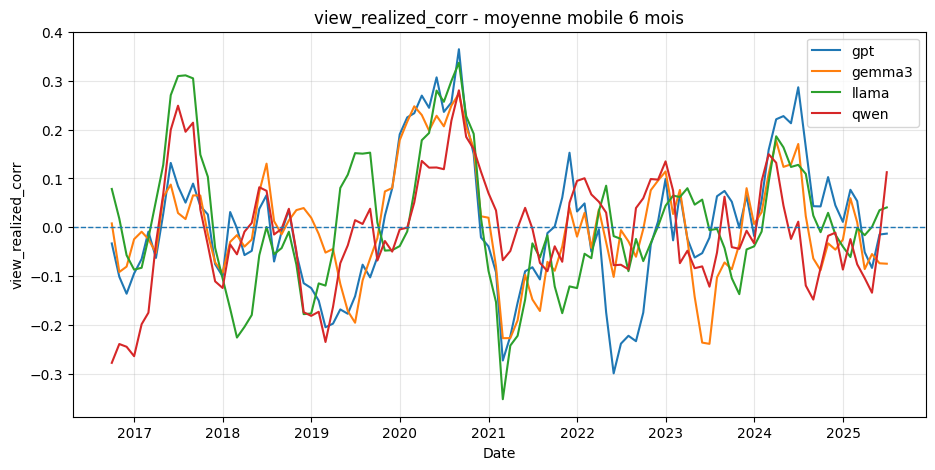

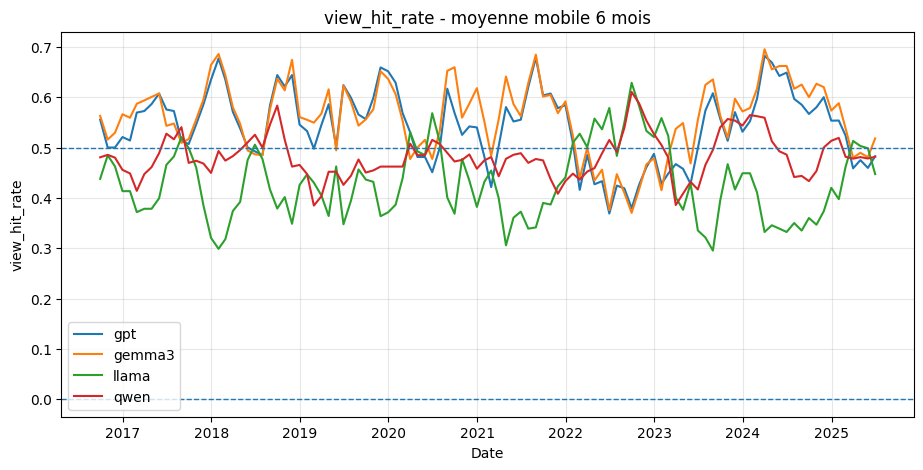

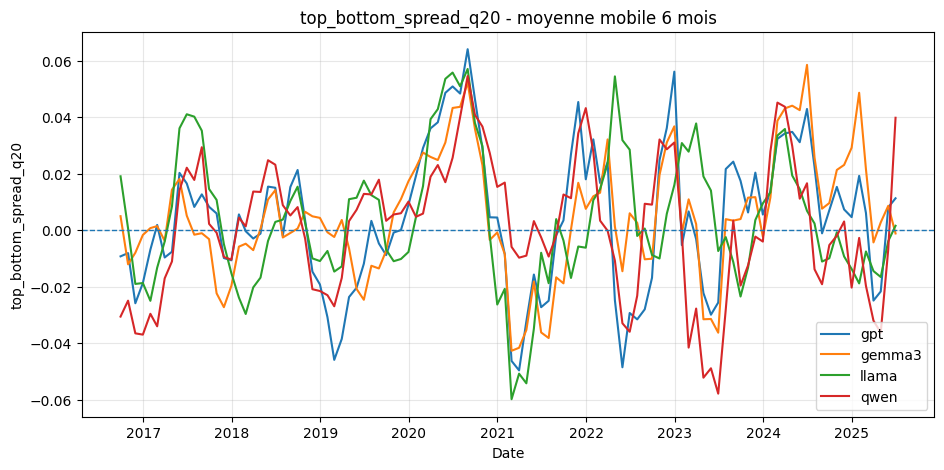

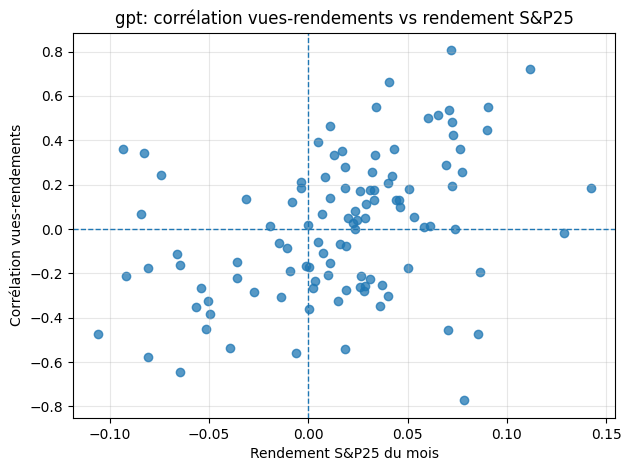

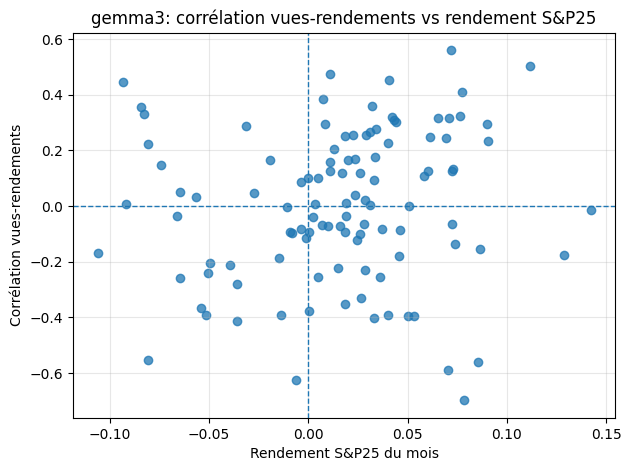

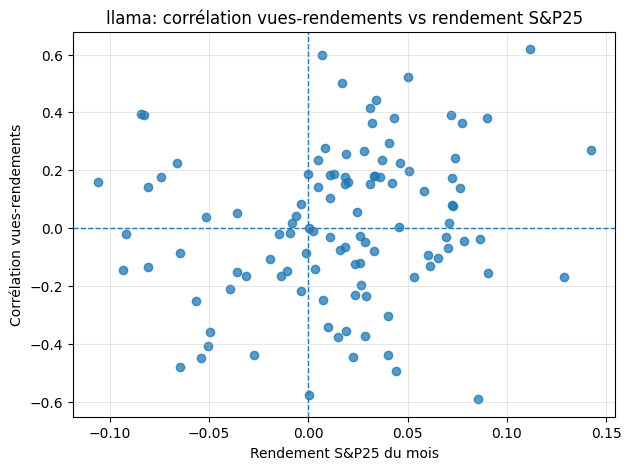

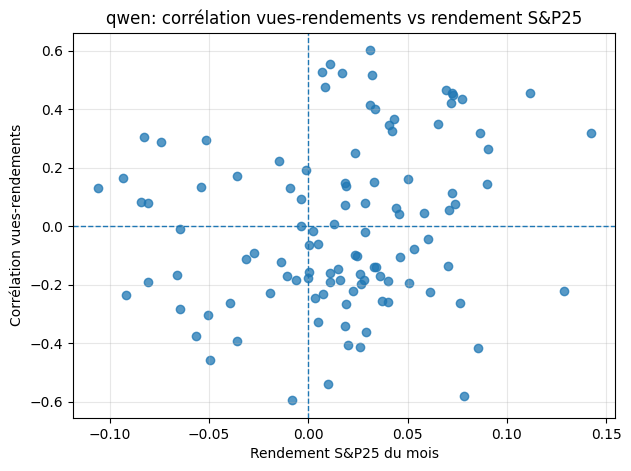

In [9]:
regime_summary = (
    views_monthly.groupby(["model", "market_regime"])
    .agg(
        n_months=("target_date", "nunique"),
        avg_sp25_return=("sp25_return", "mean"),
        avg_view_corr=("view_realized_corr", "mean"),
        avg_rank_corr=("view_realized_rank_corr", "mean"),
        avg_hit_rate=("view_hit_rate", "mean"),
        avg_top_bottom_spread=("top_bottom_spread_q20", "mean"),
        avg_top_bottom_hit=("top_bottom_hit_q20", "mean"),
        avg_view_pos_frac=("view_pos_frac", "mean"),
        avg_view_mean=("view_mean_avg", "mean"),
        avg_view_dispersion=("view_std_cross_section", "mean"),
    )
    .reset_index()
    .sort_values(["model", "market_regime"])
)

display(regime_summary)

for metric in ["view_realized_corr", "view_hit_rate", "top_bottom_spread_q20"]:
    plt.figure(figsize=(11, 5))
    for model in MODELS:
        d = views_monthly[views_monthly["model"] == model].sort_values("target_date")
        if d.empty:
            continue
        plt.plot(d["target_date"], d[metric].rolling(6, min_periods=3).mean(), label=model)
    plt.axhline(0, linestyle="--", linewidth=1)
    if metric == "view_hit_rate":
        plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.title(f"{metric} - moyenne mobile 6 mois")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for model in MODELS:
    d = views_monthly[views_monthly["model"] == model].dropna(subset=["sp25_return", "view_realized_corr"])
    if d.empty:
        continue
    plt.figure(figsize=(7, 5))
    plt.scatter(d["sp25_return"], d["view_realized_corr"], alpha=0.75)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title(f"{model}: corrélation vues-rendements vs rendement S&P25")
    plt.xlabel("Rendement S&P25 du mois")
    plt.ylabel("Corrélation vues-rendements")
    plt.grid(True, alpha=0.3)
    plt.show()


## 6. Comparaison des vues entre modèles


,pair,n_months,avg_view_corr,avg_rank_corr,avg_sign_agreement,avg_top20_jaccard,avg_bottom20_jaccard
0,gemma3 vs gpt,108,0.5907,0.5920,0.8746,0.4273,0.3455
4,gpt vs qwen,108,0.4445,0.4584,0.5806,0.2792,0.2615
5,llama vs qwen,108,0.3811,0.3839,0.6149,0.2171,0.2478
3,gpt vs llama,108,0.3403,0.2994,0.2550,0.1963,0.2194
2,gemma3 vs qwen,108,0.3373,0.3498,0.5315,0.2710,0.2094
1,gemma3 vs llama,108,0.1828,0.1388,0.1968,0.1470,0.1775


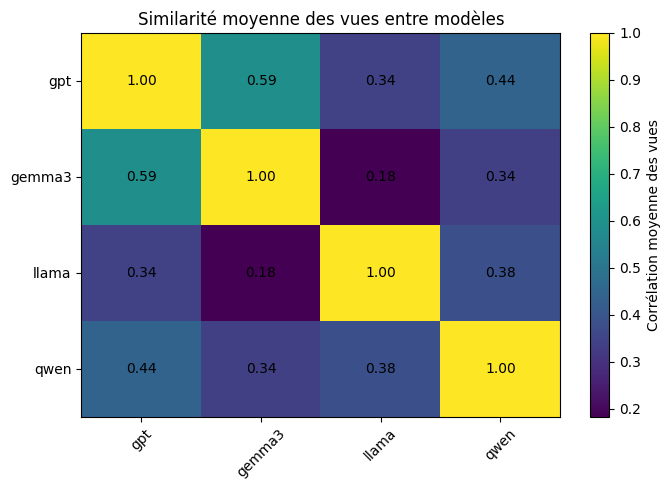

In [10]:
inter_rows = []

for target_date, gdate in views_long.groupby("target_date"):
    models_present = sorted(gdate["model"].unique())
    for m1, m2 in combinations(models_present, 2):
        g1 = gdate[gdate["model"] == m1].set_index("tic")
        g2 = gdate[gdate["model"] == m2].set_index("tic")
        common = g1.index.intersection(g2.index)

        if len(common) < 3:
            continue

        v1 = g1.loc[common, "view_mean"]
        v2 = g2.loc[common, "view_mean"]

        n_top = max(1, int(0.2 * len(common)))
        top1 = set(v1.nlargest(n_top).index)
        top2 = set(v2.nlargest(n_top).index)
        bot1 = set(v1.nsmallest(n_top).index)
        bot2 = set(v2.nsmallest(n_top).index)

        top_jaccard = len(top1 & top2) / len(top1 | top2) if len(top1 | top2) > 0 else np.nan
        bottom_jaccard = len(bot1 & bot2) / len(bot1 | bot2) if len(bot1 | bot2) > 0 else np.nan
        sign_agree = float((np.sign(v1) == np.sign(v2)).mean())

        inter_rows.append({
            "target_date": target_date,
            "model_1": m1,
            "model_2": m2,
            "pair": f"{m1} vs {m2}",
            "n_common": len(common),
            "view_corr": safe_corr(v1, v2),
            "view_rank_corr": safe_corr(v1.rank(), v2.rank()),
            "sign_agreement": sign_agree,
            "top20_jaccard": float(top_jaccard),
            "bottom20_jaccard": float(bottom_jaccard),
        })

inter_model_views = pd.DataFrame(inter_rows)

inter_summary = (
    inter_model_views.groupby("pair")
    .agg(
        n_months=("target_date", "nunique"),
        avg_view_corr=("view_corr", "mean"),
        avg_rank_corr=("view_rank_corr", "mean"),
        avg_sign_agreement=("sign_agreement", "mean"),
        avg_top20_jaccard=("top20_jaccard", "mean"),
        avg_bottom20_jaccard=("bottom20_jaccard", "mean"),
    )
    .reset_index()
    .sort_values("avg_view_corr", ascending=False)
)

display(inter_summary)

corr_mat = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for m in MODELS:
    corr_mat.loc[m, m] = 1.0

for _, row in inter_summary.iterrows():
    m1, _, m2 = row["pair"].partition(" vs ")
    corr_mat.loc[m1, m2] = corr_mat.loc[m2, m1] = row["avg_view_corr"]

plt.figure(figsize=(7, 5))
plt.imshow(corr_mat.astype(float), aspect="auto")
plt.colorbar(label="Corrélation moyenne des vues")
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=45)
plt.yticks(range(len(corr_mat.index)), corr_mat.index)
plt.title("Similarité moyenne des vues entre modèles")
for i in range(len(corr_mat.index)):
    for j in range(len(corr_mat.columns)):
        val = corr_mat.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()


## 7. Lien entre vues, poids actifs et performance des portefeuilles blended


In [11]:
def normalize_weights_df(weights_df: pd.DataFrame) -> pd.DataFrame:
    df = weights_df.copy()
    if "Date" not in df.columns:
        raise ValueError("Le fichier de poids doit contenir une colonne Date.")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce").dt.to_period("M")

    asset_cols = [c for c in df.columns if c != "Date"]
    rename_map = {c: clean_ticker(c) for c in asset_cols if clean_ticker(c)}
    df = df.rename(columns=rename_map)

    asset_cols_clean = [c for c in df.columns if c != "Date"]
    grouped = df[asset_cols_clean].apply(pd.to_numeric, errors="coerce")
    grouped = grouped.T.groupby(level=0).sum().T
    return pd.concat([df[["Date"]], grouped], axis=1)

def load_weights_for_portfolio(portfolio_id: str, tau: float = TAU) -> pd.DataFrame | None:
    path = RESULTS_DIR / f"{portfolio_id}_black_litterman_market_implied_weights_tau_{tau}.csv"
    if not path.exists():
        print(f"[WARN] Fichier de poids manquant: {path}")
        return None
    return normalize_weights_df(pd.read_csv(path))

def get_weight_row(weights_df: pd.DataFrame, period: pd.Period) -> pd.Series | None:
    row = weights_df.loc[weights_df["Date"] == period]
    if row.empty:
        return None
    s = row.drop(columns=["Date"]).iloc[0]
    return pd.to_numeric(s, errors="coerce").fillna(0.0)

weights_by_portfolio = {}
for model, pids in PORTFOLIOS_BY_MODEL.items():
    for pid in pids:
        wdf = load_weights_for_portfolio(pid, TAU)
        if wdf is not None:
            weights_by_portfolio[pid] = wdf

print("Portefeuilles chargés:", list(weights_by_portfolio.keys()))

active_rows = []

for pid, wdf in weights_by_portfolio.items():
    model = infer_model_from_portfolio_id(pid)

    for view_period_raw in sorted(views_long.loc[views_long["model"] == model, "view_month"].unique()):
        view_period = pd.Period(view_period_raw, freq="M")
        target_period = view_period + 1
        target_date = month_end_from_period(target_period)

        w_bl = get_weight_row(wdf, view_period)
        if w_bl is None or view_period not in market_weights.index:
            continue

        w_mkt = market_weights.loc[view_period].fillna(0.0)

        vg = views_long[
            (views_long["model"] == model)
            & (views_long["view_month"] == view_period)
        ].set_index("tic")

        if vg.empty:
            continue

        all_tickers = sorted(set(w_bl.index).union(w_mkt.index).union(vg.index))
        w_bl_a = w_bl.reindex(all_tickers).fillna(0.0)
        w_mkt_a = w_mkt.reindex(all_tickers).fillna(0.0)
        active_w = w_bl_a - w_mkt_a

        if target_period in returns_panel.index:
            realized = returns_panel.loc[target_period].reindex(all_tickers)
        else:
            realized = pd.Series(index=all_tickers, dtype=float)

        view_s = vg["view_mean"].reindex(all_tickers)

        ok = realized.notna() & np.isfinite(realized)
        if ok.any():
            denom_bl = w_bl_a.loc[ok].sum()
            denom_mkt = w_mkt_a.loc[ok].sum()
            ret_bl = float((w_bl_a.loc[ok] * realized.loc[ok]).sum() / denom_bl) if abs(denom_bl) > 1e-12 else np.nan
            ret_mkt = float((w_mkt_a.loc[ok] * realized.loc[ok]).sum() / denom_mkt) if abs(denom_mkt) > 1e-12 else np.nan
            active_ret = ret_bl - ret_mkt
        else:
            ret_bl = ret_mkt = active_ret = np.nan

        active_rows.append({
            "portfolio_id": pid,
            "model": model,
            "view_month": view_period,
            "target_month": target_period,
            "target_date": target_date,
            "portfolio_return": ret_bl,
            "sp25_return": ret_mkt,
            "active_return": active_ret,
            "active_share": 0.5 * float(np.abs(active_w).sum()),
            "n_nonzero": int((w_bl_a.abs() > 1e-6).sum()),
            "top5_weight": float(w_bl_a.sort_values(ascending=False).head(5).sum()),
            "largest_weight": float(w_bl_a.max()),
            "view_active_weight_corr": safe_corr(view_s, active_w),
            "view_weight_corr": safe_corr(view_s, w_bl_a),
            "active_weight_realized_corr": safe_corr(active_w, realized),
            "view_realized_corr": safe_corr(view_s, realized),
            "view_hit_rate": hit_rate(view_s, realized),
            "top_bottom_spread_q20": long_short_spread(view_s, realized, q=0.2),
        })

portfolio_monthly = pd.DataFrame(active_rows).sort_values(["portfolio_id", "target_date"]).reset_index(drop=True)

portfolio_view_summary = (
    portfolio_monthly.groupby(["portfolio_id", "model"])
    .agg(
        n_months=("target_date", "nunique"),
        ann_return=("portfolio_return", annualized_return),
        sp25_ann_return=("sp25_return", annualized_return),
        ann_active_return=("active_return", lambda x: pd.Series(x).dropna().mean() * 12),
        tracking_error=("active_return", lambda x: pd.Series(x).dropna().std(ddof=1) * np.sqrt(12)),
        max_drawdown=("portfolio_return", max_drawdown),
        avg_active_share=("active_share", "mean"),
        avg_n_nonzero=("n_nonzero", "mean"),
        avg_top5_weight=("top5_weight", "mean"),
        avg_largest_weight=("largest_weight", "mean"),
        avg_view_active_weight_corr=("view_active_weight_corr", "mean"),
        avg_view_weight_corr=("view_weight_corr", "mean"),
        avg_active_weight_realized_corr=("active_weight_realized_corr", "mean"),
        avg_view_realized_corr=("view_realized_corr", "mean"),
        avg_view_hit_rate=("view_hit_rate", "mean"),
        avg_top_bottom_spread_q20=("top_bottom_spread_q20", "mean"),
    )
    .reset_index()
)

portfolio_view_summary["information_ratio"] = (
    portfolio_view_summary["ann_active_return"] / portfolio_view_summary["tracking_error"]
)

display(portfolio_view_summary.sort_values("ann_active_return", ascending=False))


Portefeuilles chargés: ['gemma3_blend_alpha_0.25_omega_1', 'gemma3_blend_alpha_0.5_omega_1', 'gemma3_omega_x25', 'gpt_blend_alpha_0.5_omega_1', 'gpt_omega_x25', 'llama_blend_alpha_0.1_omega_1', 'qwen_blend_alpha_0.1_omega_1']


,portfolio_id,model,n_months,ann_return,sp25_ann_return,ann_active_return,tracking_error,max_drawdown,avg_active_share,avg_n_nonzero,avg_top5_weight,avg_largest_weight,avg_view_active_weight_corr,avg_view_weight_corr,avg_active_weight_realized_corr,avg_view_realized_corr,avg_view_hit_rate,avg_top_bottom_spread_q20,information_ratio
2,gemma3_omega_x25,gemma3,108,0.3298,0.1911,0.1335,0.1702,-0.3859,0.7577,4.0000,0.9937,0.5430,0.2668,0.3125,0.0608,0.0029,0.5591,0.0055,0.7845
4,gpt_omega_x25,gpt,108,0.2976,0.1911,0.1094,0.1659,-0.4311,0.7279,4.5093,0.9838,0.5092,0.3753,0.4451,0.0465,0.0075,0.5414,0.0051,0.6595
1,gemma3_blend_alpha_0.5_omega_1,gemma3,108,0.2808,0.1911,0.0830,0.1030,-0.2873,0.4434,21.8056,0.7388,0.4245,0.3066,0.3685,0.0518,0.0029,0.5591,0.0055,0.8061
3,gpt_blend_alpha_0.5_omega_1,gpt,108,0.2320,0.1911,0.0480,0.1182,-0.4277,0.4361,21.8056,0.7451,0.4778,0.4164,0.4816,0.0344,0.0075,0.5414,0.0051,0.4061
0,gemma3_blend_alpha_0.25_omega_1,gemma3,108,0.2361,0.1911,0.0409,0.0515,-0.2711,0.2236,21.8056,0.6103,0.2478,0.3090,0.3670,0.0504,0.0029,0.5591,0.0055,0.7941
6,qwen_blend_alpha_0.1_omega_1,qwen,108,0.1886,0.1911,-0.0016,0.0235,-0.2843,0.0955,21.8056,0.5365,0.1613,0.2377,0.2963,-0.0072,-0.0007,0.4827,0.0028,-0.0676
5,llama_blend_alpha_0.1_omega_1,llama,108,0.1750,0.1911,-0.0146,0.0202,-0.2774,0.0953,21.8056,0.5193,0.1485,0.2627,0.2652,-0.0454,0.0095,0.4275,0.0036,-0.7199


## 8. Graphiques : qualité des vues vs rendement actif


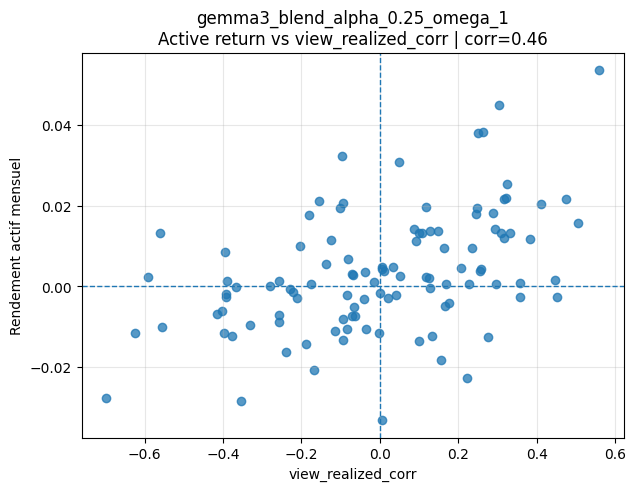

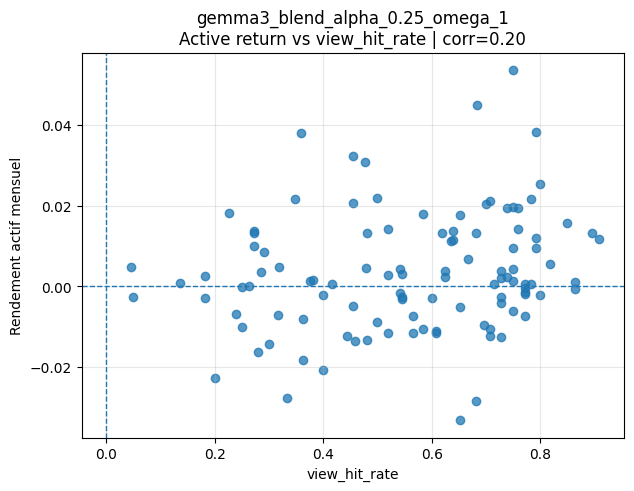

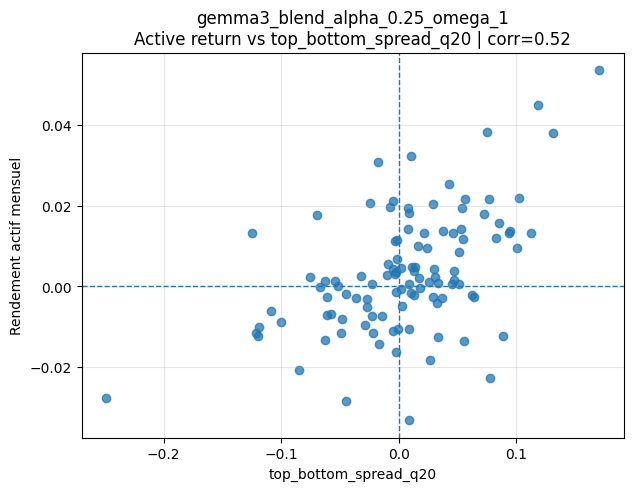

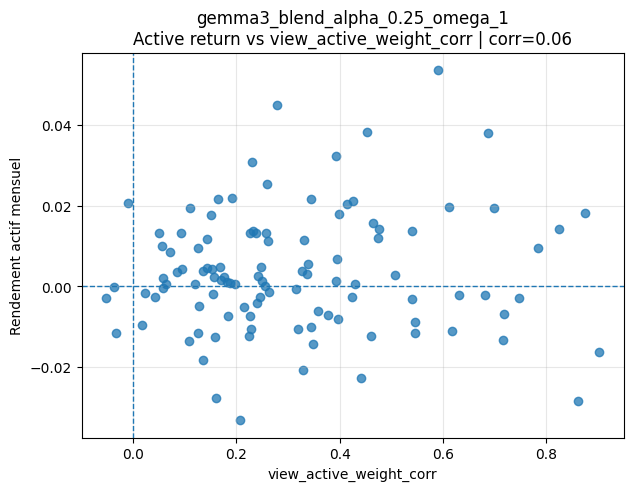

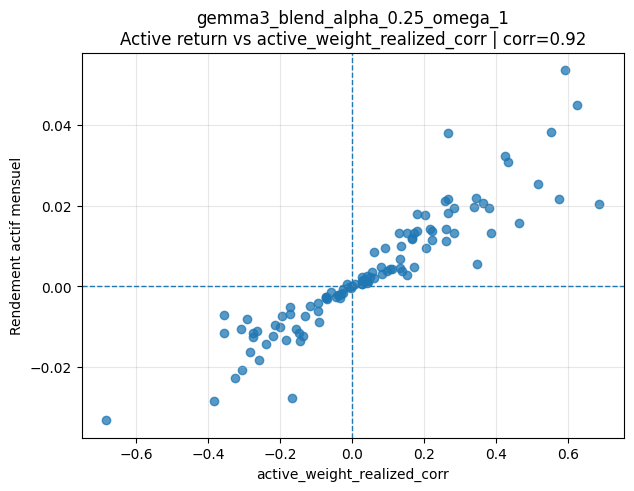

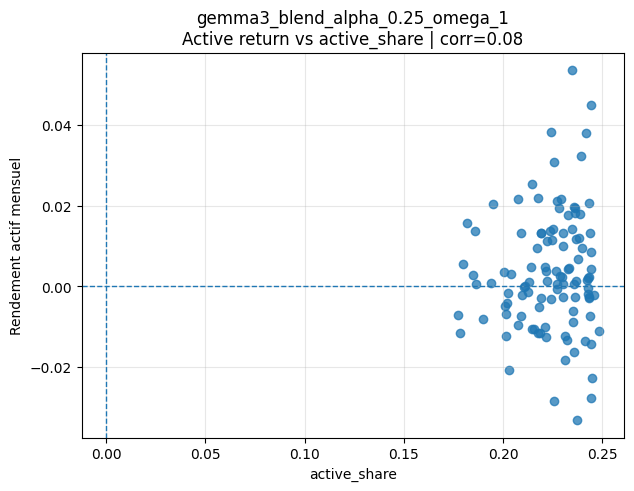

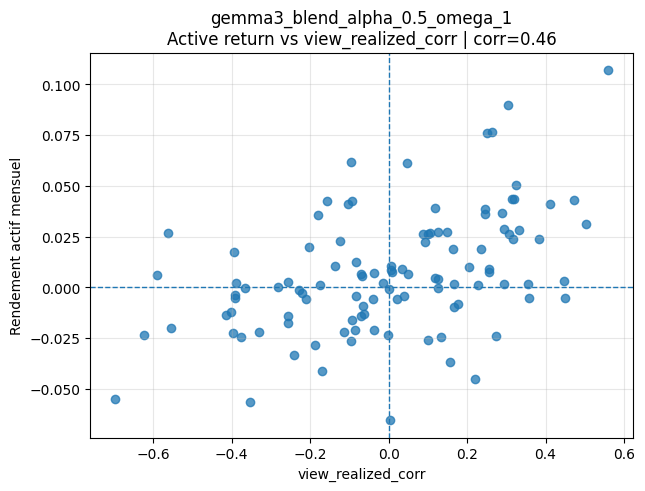

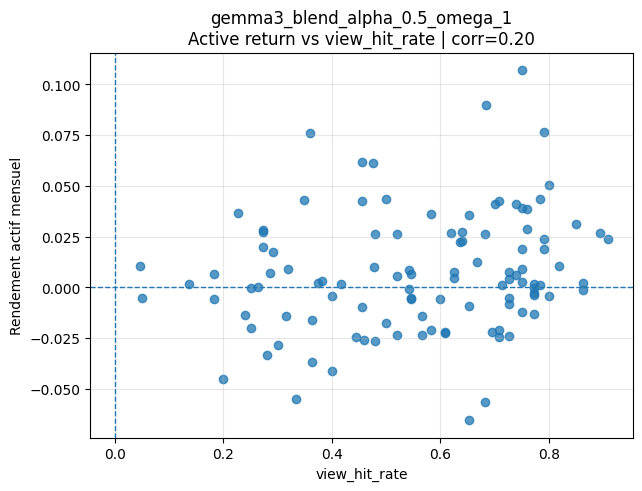

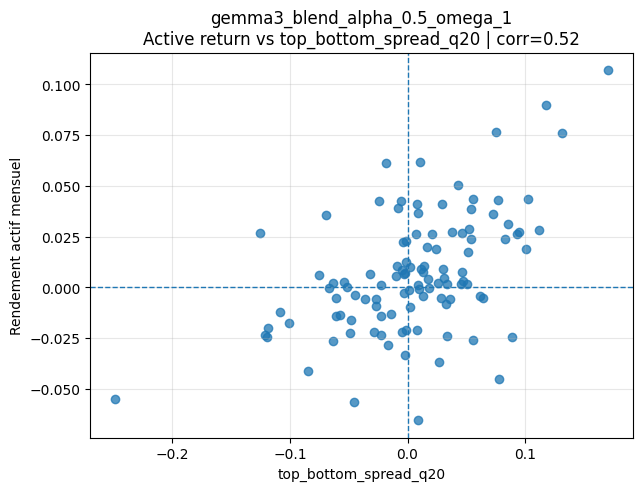

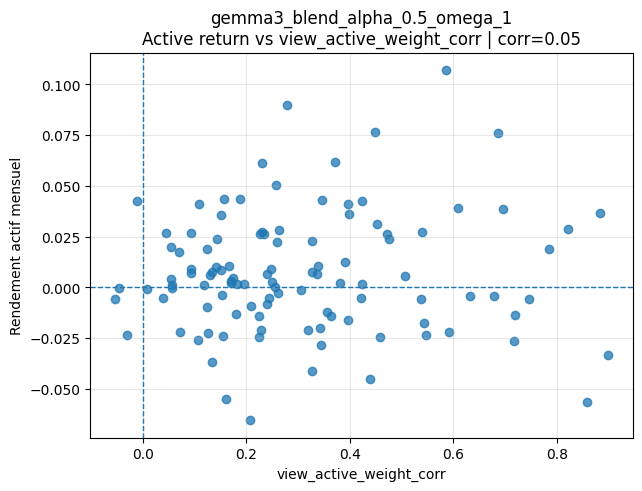

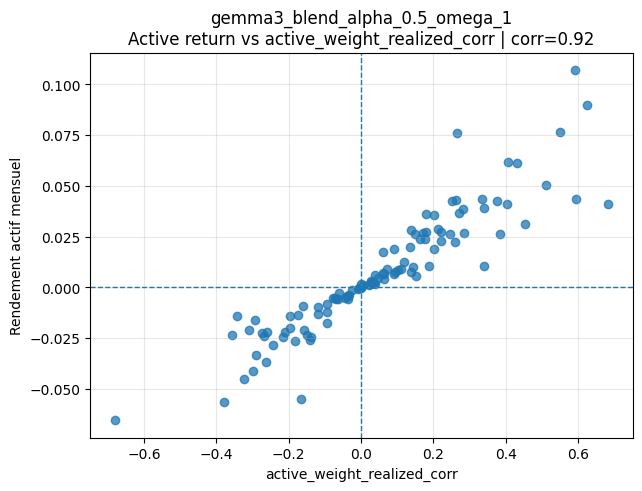

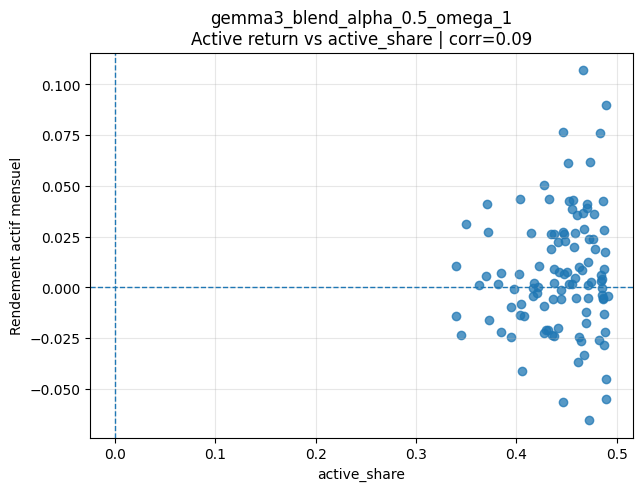

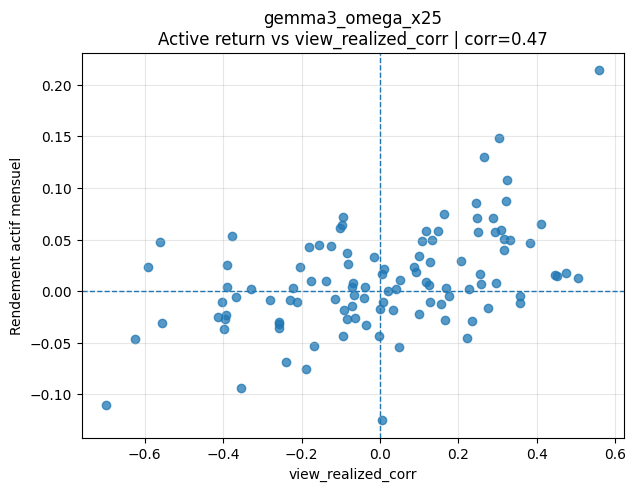

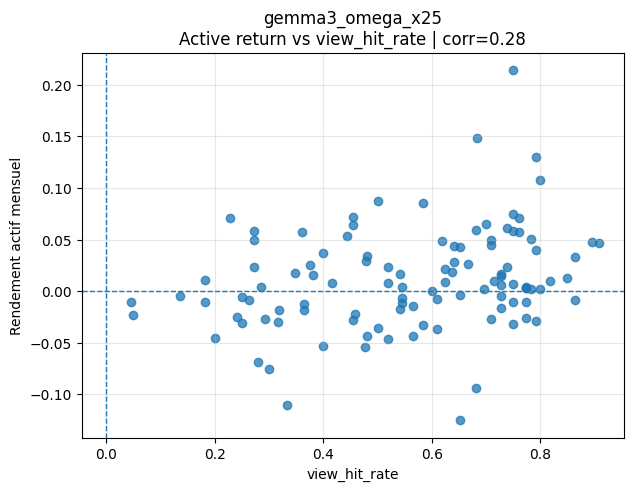

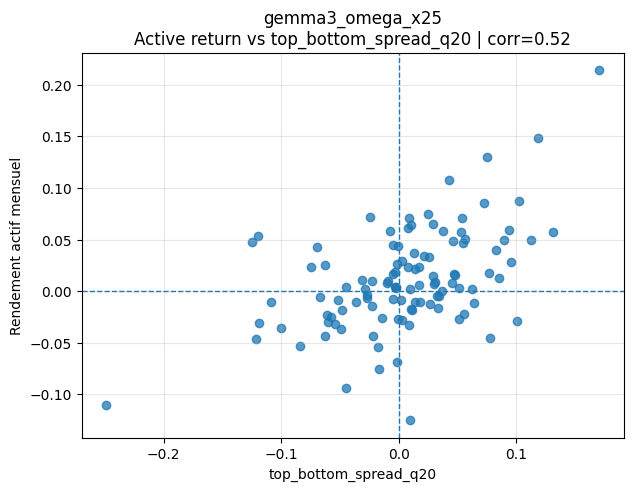

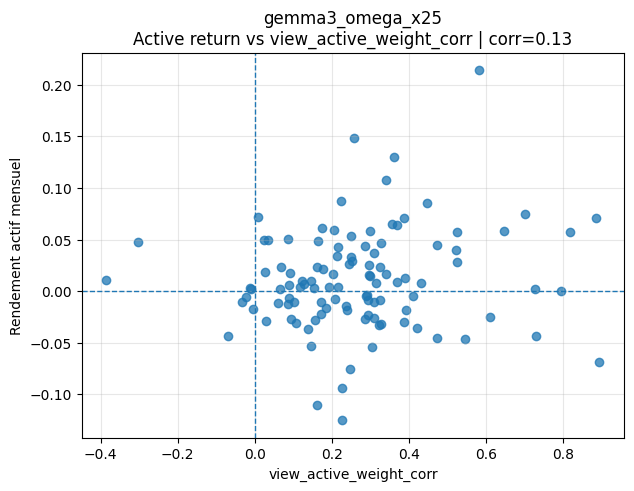

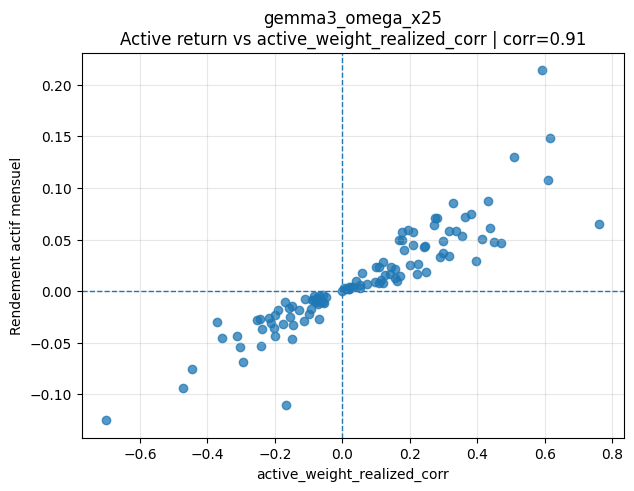

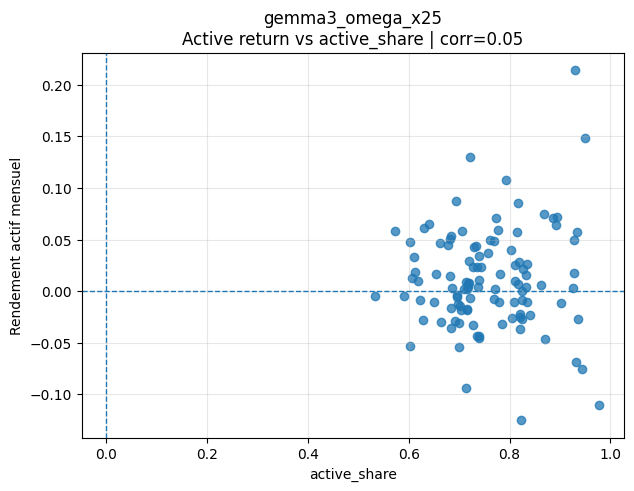

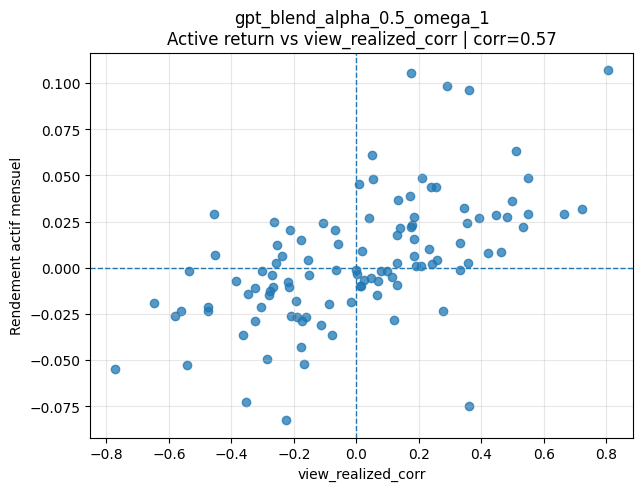

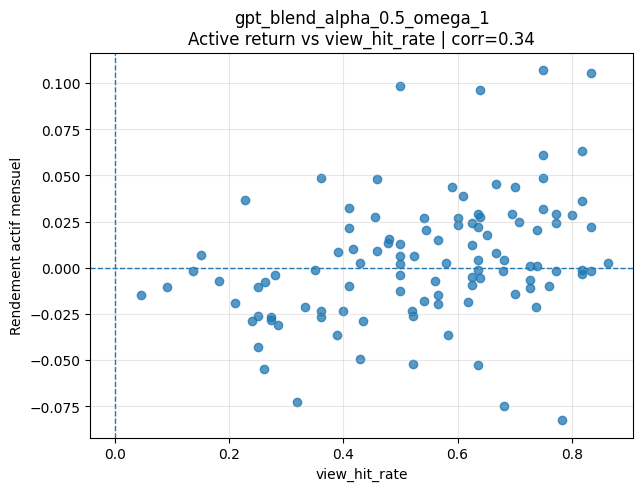

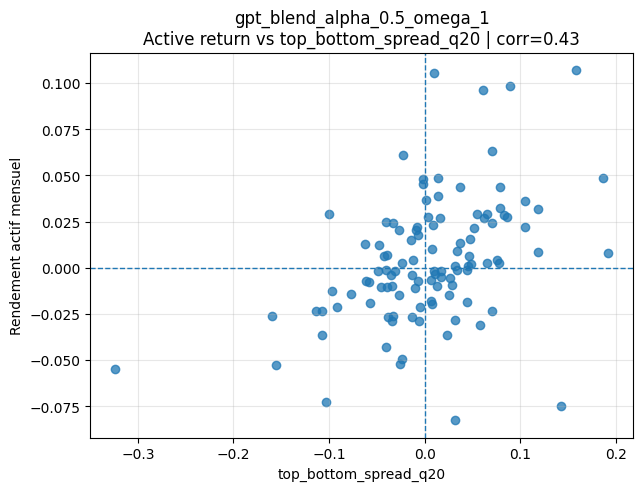

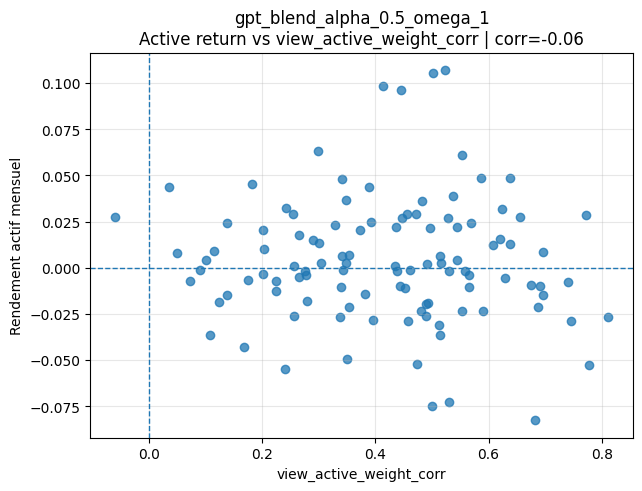

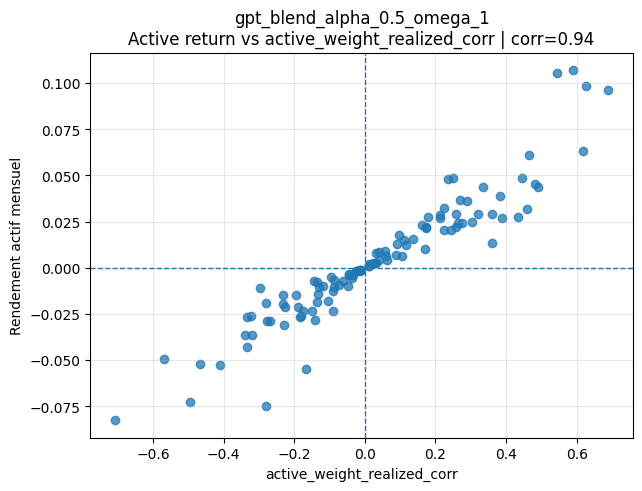

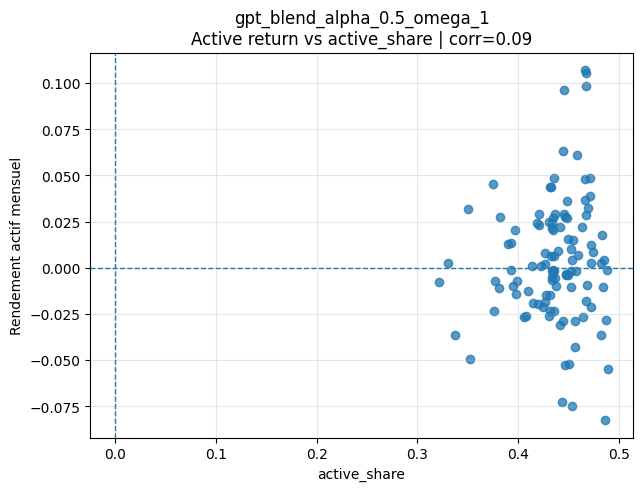

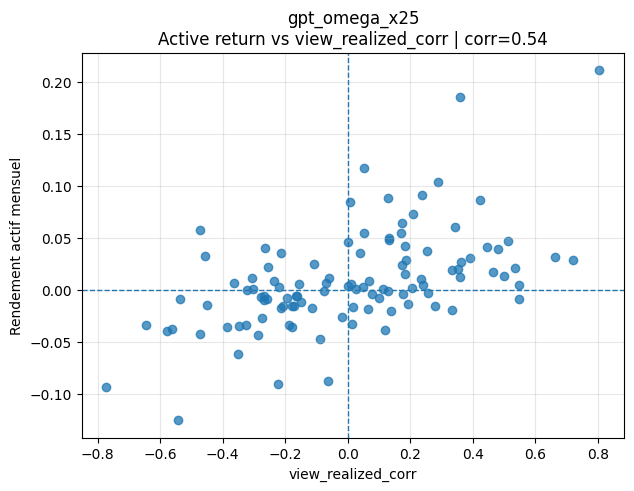

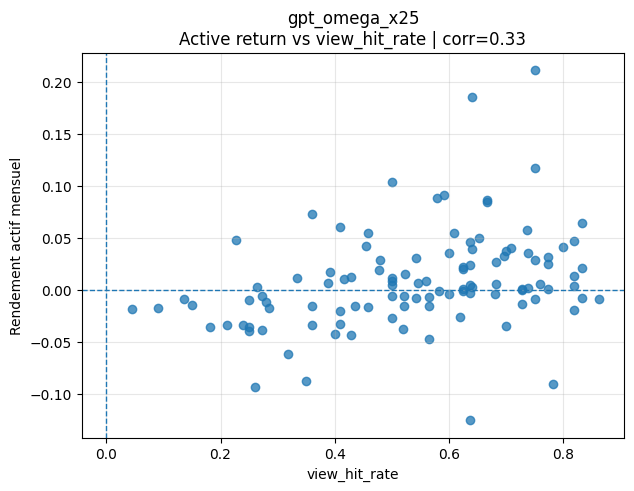

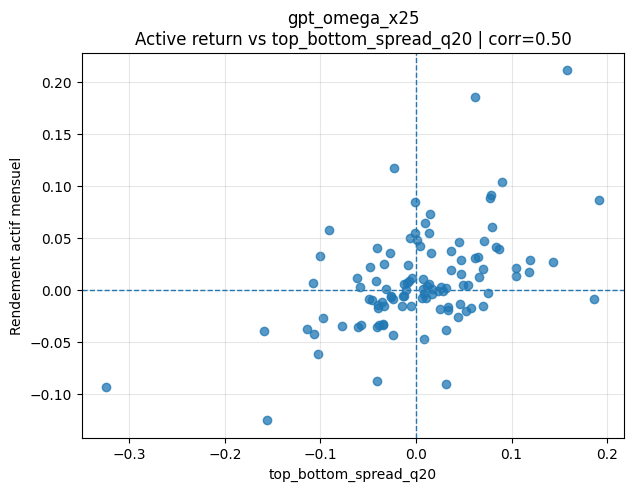

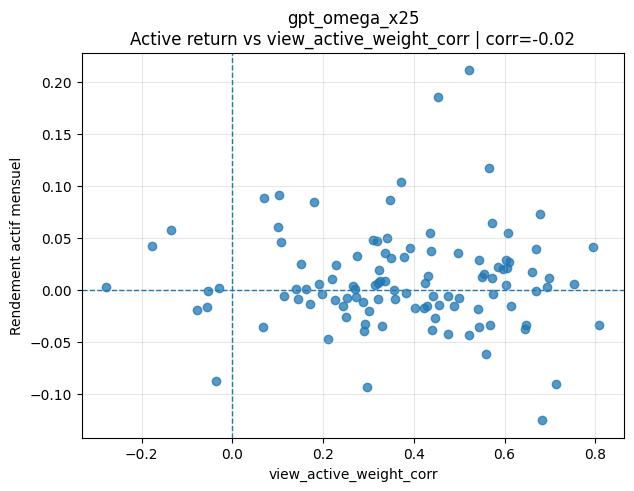

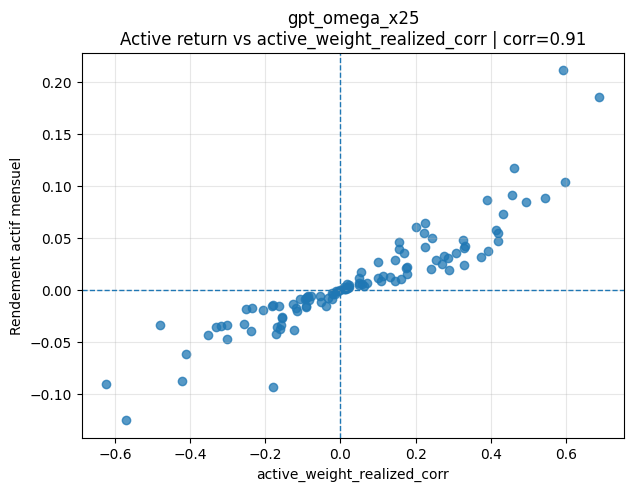

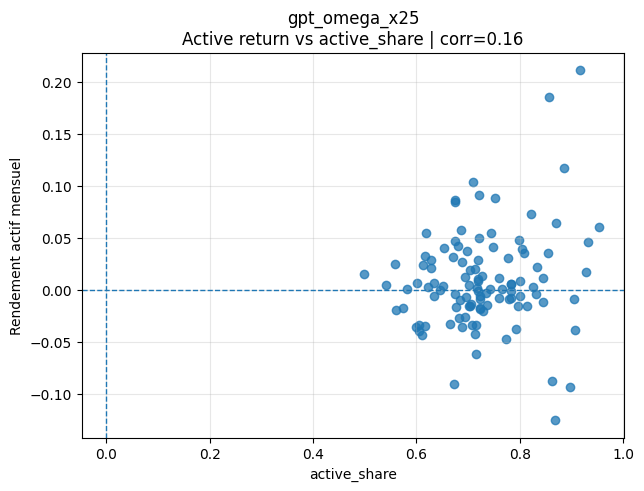

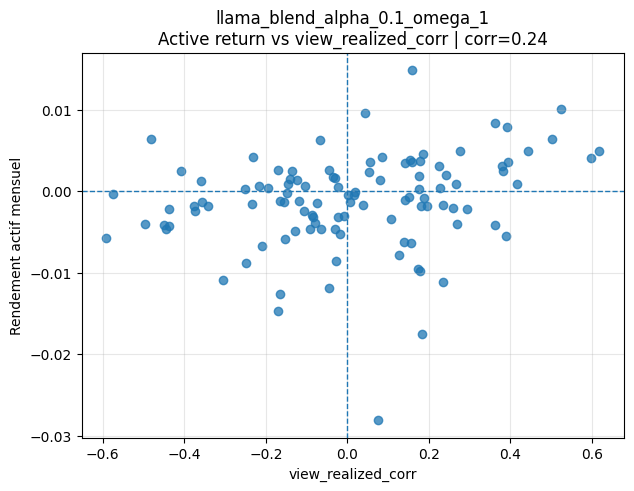

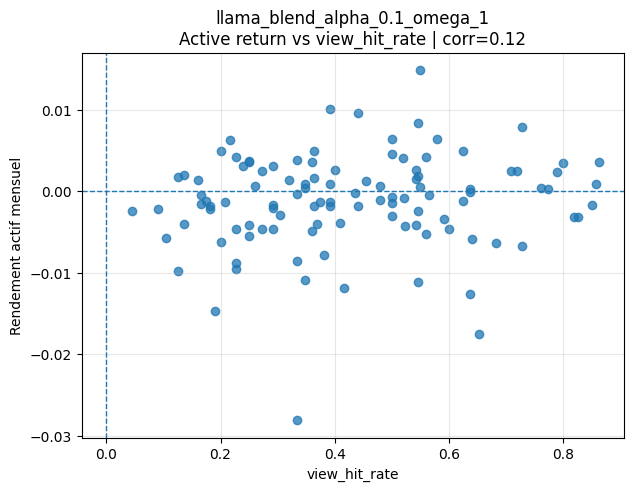

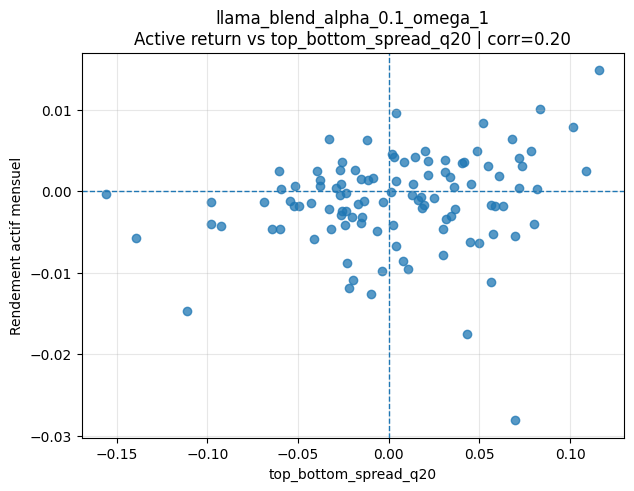

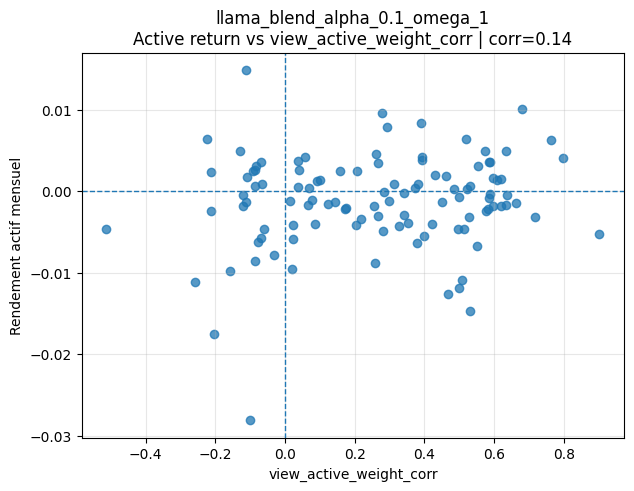

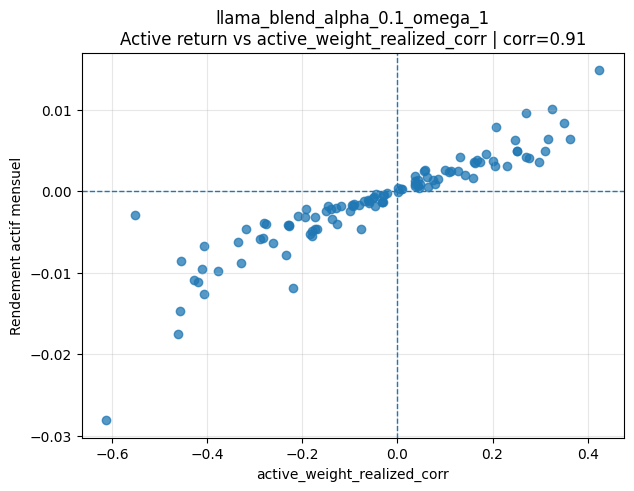

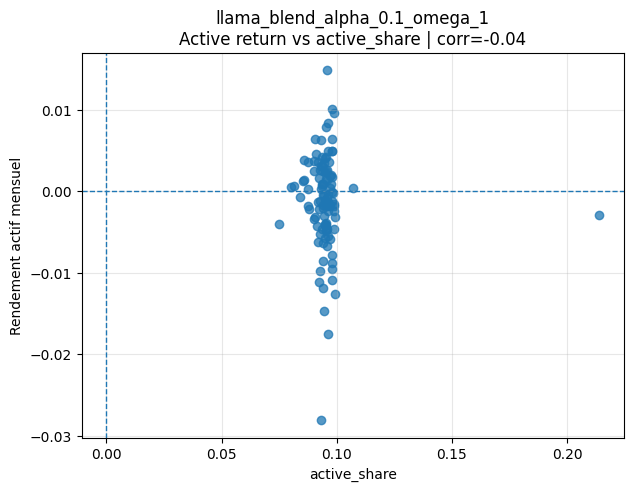

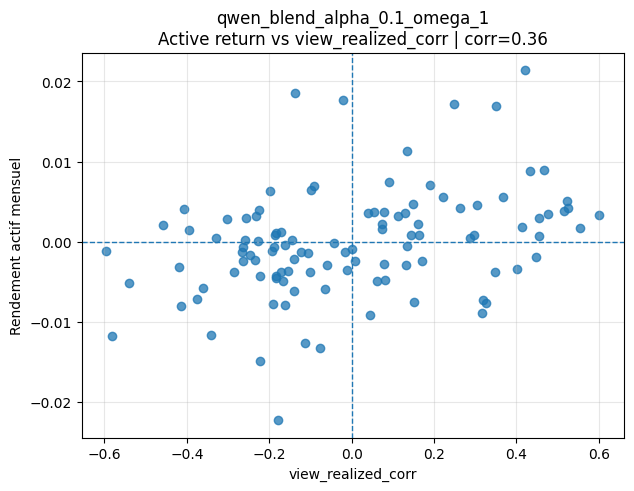

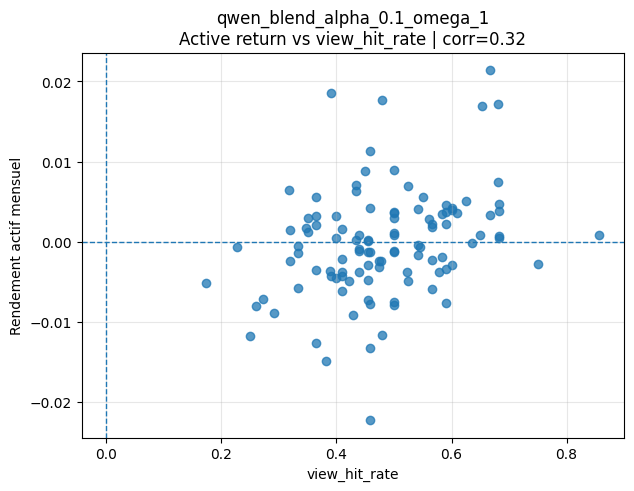

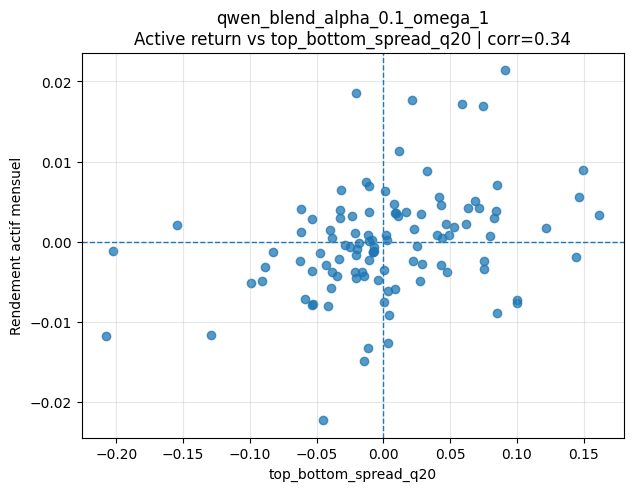

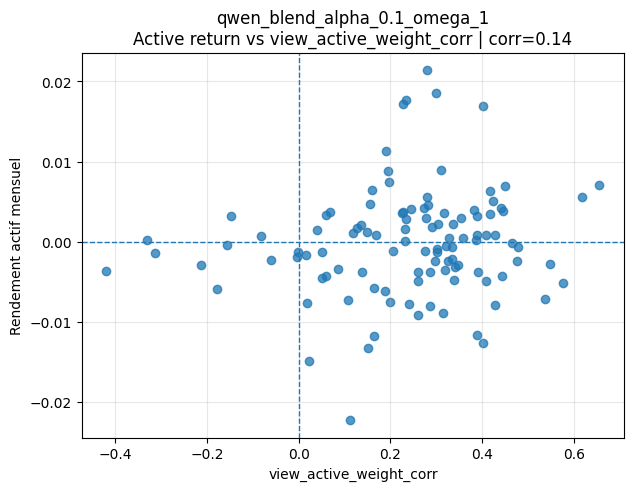

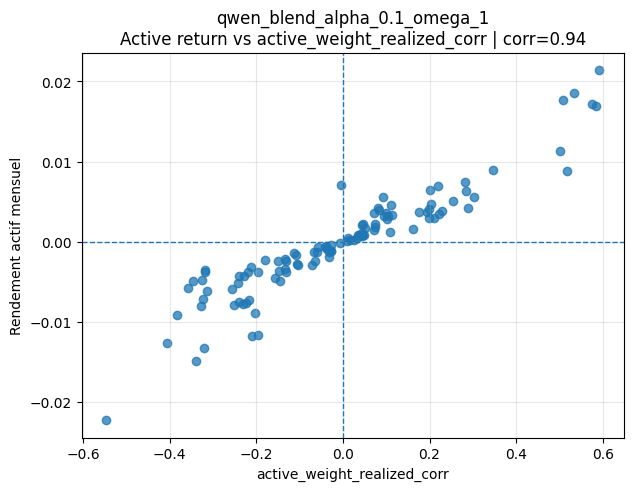

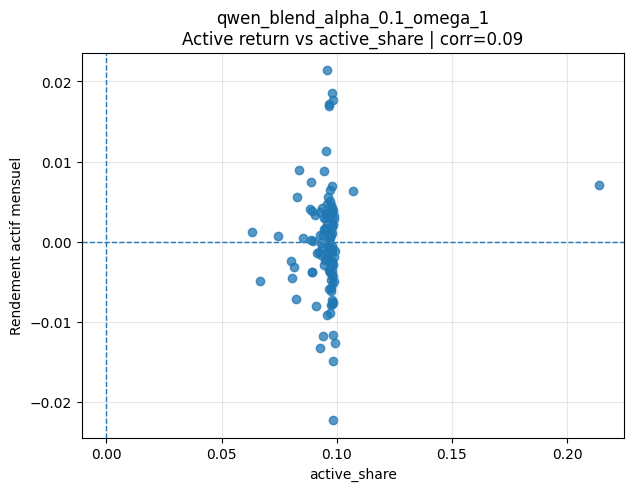

In [12]:
metrics_x = [
    "view_realized_corr",
    "view_hit_rate",
    "top_bottom_spread_q20",
    "view_active_weight_corr",
    "active_weight_realized_corr",
    "active_share",
]

for pid in portfolio_monthly["portfolio_id"].unique():
    d = portfolio_monthly[portfolio_monthly["portfolio_id"] == pid].copy()
    if d.empty:
        continue

    for xcol in metrics_x:
        dd = d.dropna(subset=[xcol, "active_return"])
        if len(dd) < 8:
            continue
        corr = safe_corr(dd[xcol], dd["active_return"])

        plt.figure(figsize=(7, 5))
        plt.scatter(dd[xcol], dd["active_return"], alpha=0.75)
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.title(f"{pid}\nActive return vs {xcol} | corr={corr:.2f}")
        plt.xlabel(xcol)
        plt.ylabel("Rendement actif mensuel")
        plt.grid(True, alpha=0.3)
        plt.show()


## 9. Performance par quartile de qualité des vues


In [13]:
quartile_rows = []

quality_metrics = ["view_realized_corr", "view_hit_rate", "top_bottom_spread_q20"]

for pid, g in portfolio_monthly.groupby("portfolio_id"):
    for metric in quality_metrics:
        d = g.dropna(subset=[metric, "active_return"]).copy()
        if len(d) < 12 or d[metric].nunique() < 4:
            continue
        d["quartile"] = pd.qcut(d[metric], q=4, labels=["Q1 weak", "Q2", "Q3", "Q4 strong"], duplicates="drop")
        for q, h in d.groupby("quartile", observed=True):
            quartile_rows.append({
                "portfolio_id": pid,
                "metric": metric,
                "quartile": str(q),
                "n_months": len(h),
                "avg_metric": h[metric].mean(),
                "avg_active_return_monthly": h["active_return"].mean(),
                "ann_active_return_approx": h["active_return"].mean() * 12,
                "hit_vs_sp25": (h["active_return"] > 0).mean(),
            })

quartile_summary = pd.DataFrame(quartile_rows)
display(quartile_summary)


,portfolio_id,metric,quartile,n_months,avg_metric,avg_active_return_monthly,ann_active_return_approx,hit_vs_sp25
0,gemma3_blend_alpha_0.25_omega_1,view_realized_corr,Q1 weak,27,-0.3616,-0.0047,-0.0559,0.2963
1,gemma3_blend_alpha_0.25_omega_1,view_realized_corr,Q2,27,-0.0766,-0.0005,-0.0060,0.4815
2,gemma3_blend_alpha_0.25_omega_1,view_realized_corr,Q3,27,0.1139,0.0031,0.0373,0.6667
3,gemma3_blend_alpha_0.25_omega_1,view_realized_corr,Q4 strong,27,0.3358,0.0157,0.1882,0.8889
4,gemma3_blend_alpha_0.25_omega_1,view_hit_rate,Q1 weak,27,0.2652,0.0002,0.0025,0.5556
...,...,...,...,...,...,...,...,...
79,qwen_blend_alpha_0.1_omega_1,view_hit_rate,Q4 strong,26,0.6423,0.0033,0.0396,0.7308
80,qwen_blend_alpha_0.1_omega_1,top_bottom_spread_q20,Q1 weak,27,-0.0721,-0.0038,-0.0460,0.2593
81,qwen_blend_alpha_0.1_omega_1,top_bottom_spread_q20,Q2,27,-0.0165,-0.0001,-0.0012,0.4074
82,qwen_blend_alpha_0.1_omega_1,top_bottom_spread_q20,Q3,27,0.0157,0.0007,0.0087,0.5926


## 10. Top picks et erreurs fréquentes


In [14]:
top_pick_rows = []

for (model, target_date), g in views_long.dropna(subset=["view_mean", "realized_next_return"]).groupby(["model", "target_date"]):
    if len(g) < 5:
        continue
    n = max(1, int(0.2 * len(g)))
    top = g.nlargest(n, "view_mean")
    bottom = g.nsmallest(n, "view_mean")

    for _, row in top.iterrows():
        top_pick_rows.append({
            "model": model,
            "target_date": target_date,
            "tic": row["tic"],
            "bucket": "top20",
            "view_mean": row["view_mean"],
            "realized_next_return": row["realized_next_return"],
        })

    for _, row in bottom.iterrows():
        top_pick_rows.append({
            "model": model,
            "target_date": target_date,
            "tic": row["tic"],
            "bucket": "bottom20",
            "view_mean": row["view_mean"],
            "realized_next_return": row["realized_next_return"],
        })

top_picks = pd.DataFrame(top_pick_rows)

top_pick_summary = (
    top_picks.groupby(["model", "tic", "bucket"])
    .agg(
        n_appearances=("target_date", "count"),
        avg_view=("view_mean", "mean"),
        avg_realized=("realized_next_return", "mean"),
        hit_rate_positive=("realized_next_return", lambda x: (pd.Series(x) > 0).mean()),
    )
    .reset_index()
    .sort_values(["model", "bucket", "n_appearances"], ascending=[True, True, False])
)

display(top_pick_summary.head(75))

bad_positive_views = (
    views_long.dropna(subset=["view_mean", "realized_next_return"])
    .assign(view_rank_pct=lambda d: d.groupby(["model", "target_date"])["view_mean"].rank(pct=True))
    .query("view_rank_pct >= 0.8 and realized_next_return < 0")
    .sort_values("realized_next_return")
)

print("Vues top20 avec rendement réalisé négatif")
display(bad_positive_views[["model", "target_date", "tic", "view_mean", "realized_next_return", "view_rank_pct"]].head(75))


,model,tic,bucket,n_appearances,avg_view,avg_realized,hit_rate_positive
73,gemma3,XOM,bottom20,42,-0.0050,0.0082,0.5952
33,gemma3,KO,bottom20,31,0.0015,0.0084,0.6774
17,gemma3,CVX,bottom20,30,-0.0070,-0.0041,0.5333
38,gemma3,META,bottom20,28,-0.0290,-0.0035,0.5000
28,gemma3,JNJ,bottom20,21,0.0079,0.0141,0.5238
...,...,...,...,...,...,...,...
52,gemma3,PFE,top20,2,0.0306,-0.0040,0.5000
58,gemma3,PYPL,top20,2,0.0643,-0.0035,0.5000
68,gemma3,VZ,top20,2,0.0258,0.0470,1.0000
27,gemma3,INTC,top20,1,0.0258,0.0628,1.0000


Vues top20 avec rendement réalisé négatif


,model,target_date,tic,view_mean,realized_next_return,view_rank_pct
6178,qwen,2022-02-28,META,0.0341,-0.3263,0.9545
6156,llama,2022-02-28,META,0.0108,-0.3263,0.8182
6304,gemma3,2022-04-30,NVDA,0.0483,-0.3203,0.9500
6284,gpt,2022-04-30,NVDA,0.0642,-0.3203,1.0000
8215,gpt,2024-01-31,TSLA,0.0835,-0.2463,0.9167
...,...,...,...,...,...,...
8479,qwen,2024-03-31,TSLA,0.0866,-0.1292,0.8333
6410,llama,2022-05-31,TSLA,0.0153,-0.1292,0.9524
6431,qwen,2022-05-31,TSLA,0.0361,-0.1292,0.9048
6389,gemma3,2022-05-31,TSLA,0.0341,-0.1292,0.9048


## 11. Exports


In [15]:
# views_long_path = OUT_DIR / f"views_long_{START}_{END}.csv"
# views_monthly_path = OUT_DIR / f"views_monthly_diagnostics_{START}_{END}.csv"
# views_summary_path = OUT_DIR / f"views_summary_{START}_{END}.csv"
# regime_summary_path = OUT_DIR / f"views_regime_summary_{START}_{END}.csv"
# inter_summary_path = OUT_DIR / f"views_inter_model_summary_{START}_{END}.csv"
# portfolio_monthly_path = OUT_DIR / f"blended_portfolio_views_monthly_{START}_{END}.csv"
# portfolio_summary_path = OUT_DIR / f"blended_portfolio_views_summary_{START}_{END}.csv"
# quartile_summary_path = OUT_DIR / f"quartile_summary_{START}_{END}.csv"
# top_pick_summary_path = OUT_DIR / f"top_pick_summary_{START}_{END}.csv"
# excel_path = OUT_DIR / f"blended_views_analysis_report_{START}_{END}.xlsx"

# views_long.to_csv(views_long_path, index=False)
# views_monthly.to_csv(views_monthly_path, index=False)
# views_summary.to_csv(views_summary_path, index=False)
# regime_summary.to_csv(regime_summary_path, index=False)
# inter_summary.to_csv(inter_summary_path, index=False)
# portfolio_monthly.to_csv(portfolio_monthly_path, index=False)
# portfolio_view_summary.to_csv(portfolio_summary_path, index=False)
# quartile_summary.to_csv(quartile_summary_path, index=False)
# top_pick_summary.to_csv(top_pick_summary_path, index=False)

# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     views_summary.to_excel(writer, sheet_name="views_summary", index=False)
#     views_monthly.to_excel(writer, sheet_name="views_monthly", index=False)
#     regime_summary.to_excel(writer, sheet_name="regime_summary", index=False)
#     inter_summary.to_excel(writer, sheet_name="inter_model_summary", index=False)
#     portfolio_view_summary.to_excel(writer, sheet_name="portfolio_summary", index=False)
#     portfolio_monthly.to_excel(writer, sheet_name="portfolio_monthly", index=False)
#     quartile_summary.to_excel(writer, sheet_name="quartile_summary", index=False)
#     top_pick_summary.to_excel(writer, sheet_name="top_pick_summary", index=False)
#     bad_positive_views.head(1000).to_excel(writer, sheet_name="bad_positive_views", index=False)

# print("Exports créés :")
# for p in [
#     views_long_path,
#     views_monthly_path,
#     views_summary_path,
#     regime_summary_path,
#     inter_summary_path,
#     portfolio_monthly_path,
#     portfolio_summary_path,
#     quartile_summary_path,
#     top_pick_summary_path,
#     excel_path,
# ]:
#     print("-", p)


## Guide d'interprétation rapide

- `avg_view_realized_corr` : capacité des vues à classer les titres selon les rendements futurs.
- `avg_hit_rate` : proportion de signes correctement prédits.
- `avg_top_bottom_spread_q20` : rendement moyen des titres top 20 % selon le LLM moins bottom 20 %.
- `regime_summary` : indique si le modèle fonctionne mieux en marchés haussiers ou baissiers.
- `avg_view_active_weight_corr` : vérifie si les vues se traduisent vraiment en surpondérations.
- `avg_active_weight_realized_corr` : mesure si les positions actives ont été récompensées.
- `inter_model_summary` : mesure la redondance ou la complémentarité des modèles.
